# Experiment 1 — Modeling Color Differences

**Replication of Szafir, *Modeling Color Difference for Visualization Design* (IEEE TVCG 2018), with a color-practice extension.**

This notebook is supplementary material for *Ten Years Later: Replicating Two Color Discrimination Studies*. It reproduces the analysis of Experiment 1 (Sec. 3 of the paper):

- **Part A — Replication.** Participants judged whether two colored target marks in a scatterplot were the same color or different, with target colors differing along a single CIELAB axis (L\*, a\*, or b\*) and mark sizes from 0.25° to 2.0° of visual angle. We fit the original model $p = m_x \, \Delta x$ per axis × size, derive 50% JND thresholds $ND(50\%) = 0.5 / m_x$, and compare against the original study's results.
- **Part B — Extension.** We partition participants into **Known Color Practice** and **Unknown Color Practice** groups from post-study questionnaires (makeup use, color-theory education, color-related hobbies) and test whether color practice affects color discrimination.

**Data.** The gitignored ReVISit exports must be present in `analysis/exp1/data/`: `colormap-makeup-{L,a,b}_all.json` (plus `scatterplots_metadata.json`, which is checked in). The statistics pipeline lives in `analysis/python/color_analysis/` and mirrors the TypeScript implementation of the interactive dashboard (`analysis/exp1/`).

**Run.** From `analysis/`: `uv sync`, then `uv run jupyter lab exp1/results.ipynb` (or `uv run jupyter execute exp1/results.ipynb`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

from color_analysis.exp1 import (
    AXIS_COLORS,
    AXIS_MAIN_COLORS,
    CHART_AXIS_STROKE,
    CHART_MUTED_FILL,
    CHART_TEXT_FILL,
    GROUP_COLORS,
    JND_DASH,
    JND_LINE_WIDTH,
    JND_PLOT_X_MIN,
    JND_PLOT_Y_MIN,
    ORIGINAL_PAPER_RESULTS,
    SCATTER_POINT_STROKE,
    apply_exclusion,
    build_makeup_stimulus_key_set,
    build_trial_dataframe,
    compare_to_reference,
    compute_discriminability,
    fit_inverse_size_model,
    fit_nd_linear_model,
    fit_size_axis_regressions,
    load_all_data,
    load_foundation_colors,
)
from color_analysis.exp1.stats import participant_accuracy
from color_analysis.expert_clause import (
    get_default_expert_clause,
    get_expert_clause_summary,
    get_participants_by_expert_clause,
)
from color_analysis.stats_common import cohens_d_paired, welch_t_test

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

AXES = ["L", "a", "b"]
AXIS_LABELS = {"L": "L*", "a": "a*", "b": "b*"}
SIZES = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

pd.set_option("display.precision", 4)


## 1. Load data and cohort overview

We load the three ReVISit condition exports (one study per CIELAB axis), join every scatterplot trial with its ground-truth stimulus metadata (ΔE, mark size, axis), and keep the **standard** trials for analysis. Each participant also completed 7 engagement-check trials (4 identical-color, 3 large-difference), which are excluded from the model fits.

In [2]:
data = load_all_data()
metadata = data["metadata"]
demographics = data["demographics"]
experiment_info = data["experiment_info"]
attention_checks = data["attention_checks"]

trials = build_trial_dataframe(data["responses"], metadata)
analysis_trials, participant_summary = apply_exclusion(trials)

n_participants = trials["participantId"].nunique()
by_condition = (
    trials.groupby("condition")["participantId"].nunique().reindex(AXES)
)

ac_rows = [
    {
        "participantId": pid,
        "passed": sum(c["is_correct"] for c in checks),
        "total": len(checks),
    }
    for pid, checks in attention_checks.items()
]
ac_df = pd.DataFrame(ac_rows)

cb_rows = [
    {
        "participantId": pid,
        "passed": info["color_blindness_passed"],
        "total": info["color_blindness_total"],
    }
    for pid, info in experiment_info.items()
]
cb_df = pd.DataFrame(cb_rows)

print(f"Participants (after exclusions): {n_participants}")
print(f"Participants per condition:      L*: {by_condition['L']}, a*: {by_condition['a']}, b*: {by_condition['b']}")
print(f"Total scatterplot trials:        {len(trials):,}")
print(f"Standard trials for analysis:    {len(analysis_trials):,}")
print(f"Attention checks:                {ac_df['passed'].sum()}/{ac_df['total'].sum()} passed "
      f"({ac_df['passed'].sum() / ac_df['total'].sum():.1%})")
print(f"Ishihara plates:                 {cb_df['passed'].sum()}/{cb_df['total'].sum()} correct "
      f"({cb_df['passed'].sum() / cb_df['total'].sum():.1%})")

Participants (after exclusions): 144
Participants per condition:      L*: 48, a*: 48, b*: 48
Total scatterplot trials:        11,376
Standard trials for analysis:    10,368
Attention checks:                1000/1008 passed (99.2%)
Ishihara plates:                 570/576 correct (99.0%)


### 1.1 Demographics

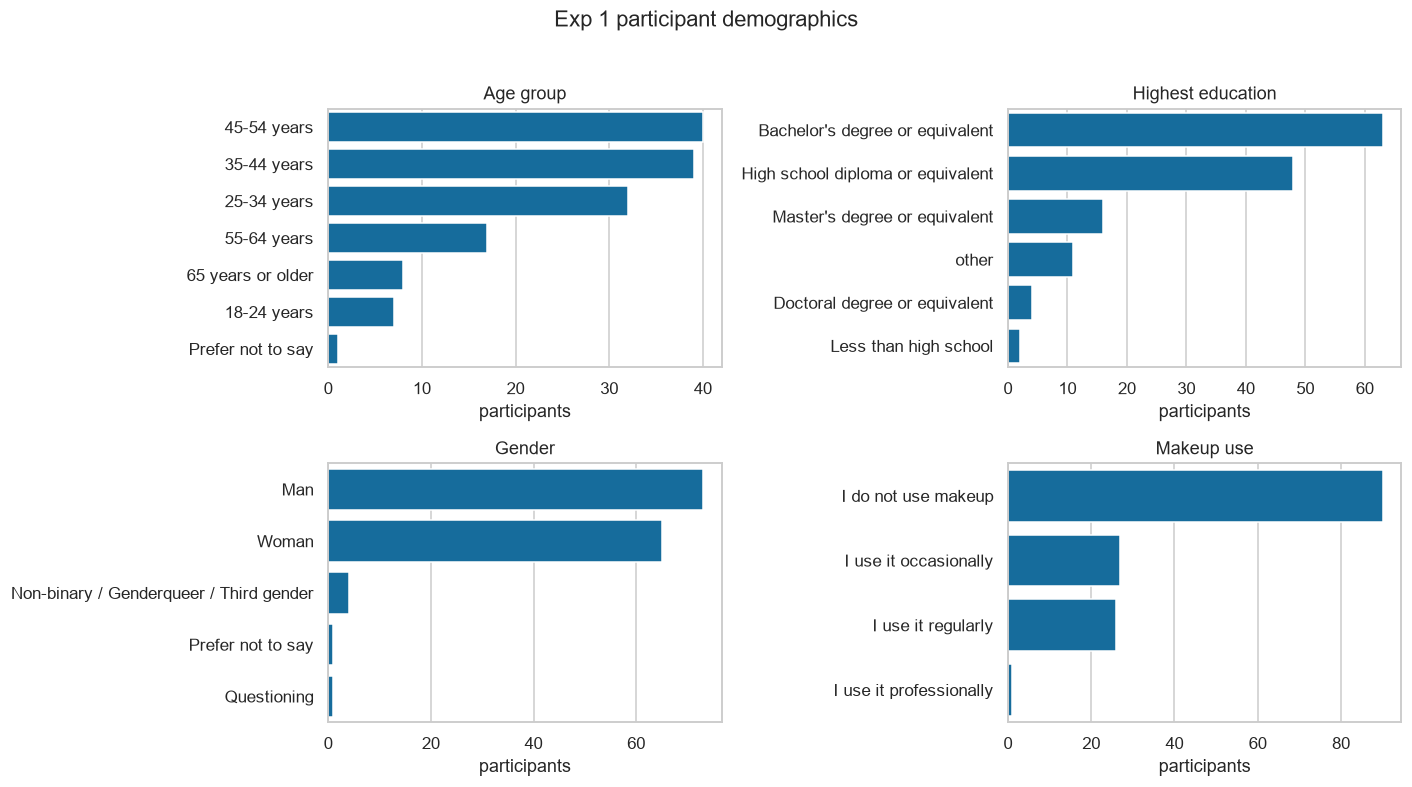

count  share
question           answer                                         
age                45-54 years                           40  27.8%
                   35-44 years                           39  27.1%
                   25-34 years                           32  22.2%
                   55-64 years                           17  11.8%
                   65 years or older                      8   5.6%
                   18-24 years                            7   4.9%
                   Prefer not to say                      1   0.7%
education          Bachelor's degree or equivalent       63  43.8%
                   High school diploma or equivalent     48  33.3%
                   Master's degree or equivalent         16  11.1%
                   other                                 11   7.6%
                   Doctoral degree or equivalent          4   2.8%
                   Less than high school                  2   1.4%
color_theory_class No                                   126  87.5%
                   Yes                                   18  12.5%
use_makeup         I do not use makeup                   90  62.5%
                   I use it occasionally                 27  18.8%
                   I use it regularly                    26  18.1%
                   I use it professionally                1   0.7%

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(13, 7))
for ax, column, title in zip(
    axs.flat,
    ["age", "education", "gender", "use_makeup"],
    ["Age group", "Highest education", "Gender", "Makeup use"],
):
    counts = demographics[column].value_counts()
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax, color=SCATTER_POINT_STROKE)
    ax.set_title(title)
    ax.set_xlabel("participants")
    ax.set_ylabel("")
fig.suptitle("Exp 1 participant demographics", y=1.02)
fig.tight_layout()
plt.show()

demo_summary = pd.concat(
    {
        column: pd.DataFrame(
            {
                "count": demographics[column].value_counts(),
                "share": (demographics[column].value_counts() / len(demographics)).map(
                    "{:.1%}".format
                ),
            }
        )
        for column in ["age", "education", "color_theory_class", "use_makeup"]
    },
    names=["question", "answer"],
)
demo_summary

### 1.2 Task engagement: duration vs. accuracy

Overall accuracy per participant against total experiment duration, as a data-quality check. Points are colored by condition; no systematic speed–accuracy trade-off should be visible.

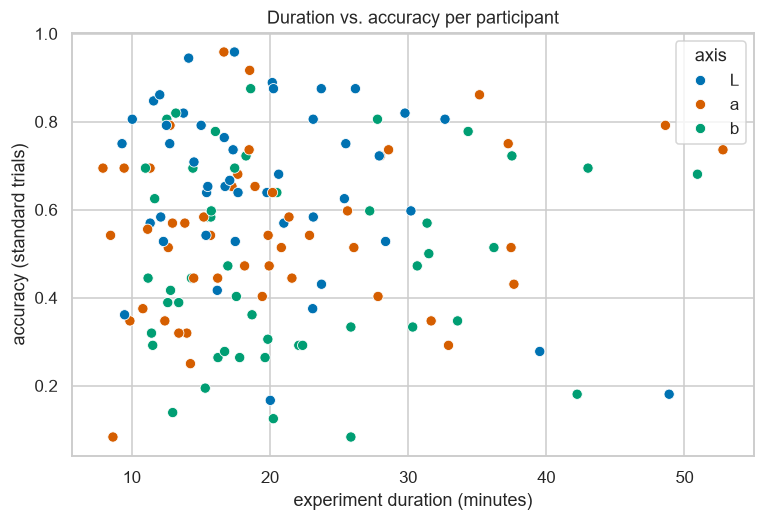

accuracy        duration_min        
              mean    std         mean     std
condition                                     
L            0.656  0.191       19.556   7.891
a            0.554  0.181       20.564  10.262
b            0.481  0.213       21.521   9.669

In [4]:
overview = participant_accuracy(analysis_trials)
overview["condition"] = overview["participantId"].map(
    trials.drop_duplicates("participantId").set_index("participantId")["condition"]
)
overview["duration_min"] = overview["participantId"].map(
    {pid: info["duration_minutes"] for pid, info in experiment_info.items()}
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=overview, x="duration_min", y="accuracy",
    hue="condition", hue_order=AXES, palette=AXIS_MAIN_COLORS, s=45, ax=ax,
)
ax.set_xlabel("experiment duration (minutes)")
ax.set_ylabel("accuracy (standard trials)")
ax.set_title("Duration vs. accuracy per participant")
ax.legend(title="axis")
plt.show()

overview.groupby("condition")[["accuracy", "duration_min"]].agg(["mean", "std"]).round(3)

## Part A — Replication of Szafir (2018)

### 2. Regression: $p = m_x \, \Delta x$

For each axis × mark size we fit the original through-origin model $p = m_x \, \Delta x$ and derive the 50% just-noticeable difference $ND(50\%) = 0.5 / m_x$. This reproduces **Table 1 of the paper's supplemental material**, side by side with the original study's values.

In [5]:
discriminability = compute_discriminability(analysis_trials)
regression = fit_size_axis_regressions(discriminability)
regression_comparison, inverse_comparison = compare_to_reference(
    regression, fit_inverse_size_model(regression)
)

supp_table = regression_comparison[
    ["axis", "size_deg", "current_slope", "ref_slope", "slope_pct_diff",
     "current_r2", "ref_r2", "current_nd50", "ref_nd50"]
].rename(
    columns={
        "size_deg": "size (°)",
        "current_slope": "our slope",
        "ref_slope": "original slope",
        "slope_pct_diff": "%diff",
        "current_r2": "our R²",
        "ref_r2": "original R²",
        "current_nd50": "our ND(50%)",
        "ref_nd50": "original ND(50%)",
    }
)
supp_table.style.format(
    {"our slope": "{:.4f}", "original slope": "{:.4f}", "%diff": "{:+.1f}",
     "our R²": "{:.3f}", "original R²": "{:.3f}",
     "our ND(50%)": "{:.2f}", "original ND(50%)": "{:.2f}"}
).hide(axis="index")

axis,size (°),our slope,original slope,%diff,our R²,original R²,our ND(50%),original ND(50%)
L,0.250000,0.0591,0.0590,+0.2,0.969,0.948,8.46,8.37
L,0.500000,0.0754,0.0740,+1.9,0.987,0.970,6.63,6.74
L,0.750000,0.0944,0.0870,+8.5,0.970,0.981,5.30,5.75
L,1.000000,0.0922,0.0870,+5.9,0.966,0.965,5.42,5.75
L,1.500000,0.1011,0.0820,+23.3,0.945,0.996,4.95,6.08
L,2.000000,0.1084,0.0910,+19.2,0.962,0.974,4.61,5.47
a,0.250000,0.0360,0.0310,+16.1,0.979,0.984,13.89,16.11
a,0.500000,0.0499,0.0500,-0.1,0.984,0.988,10.01,9.98
a,0.750000,0.0628,0.0590,+6.4,0.982,0.987,7.96,8.52
a,1.000000,0.0636,0.0640,-0.7,0.968,0.992,7.87,7.81


### 4. 50% JND thresholds vs. the original study (paper Fig. 2, top)

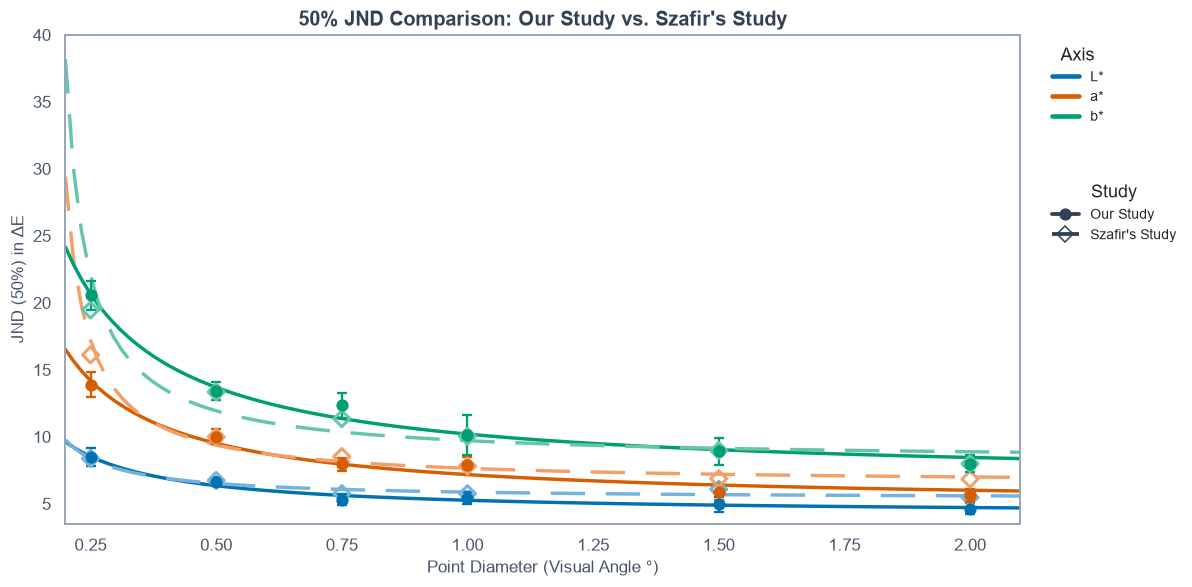

In [6]:
def plot_jnd_comparison(reg_tables: dict, title: str, reference: dict | None = None):
    """ND(50%) vs mark size, one panel per axis.

    Color encodes the CIELAB axis (Okabe–Ito main hues). When two cohort tables
    are supplied, the first uses the solid/main series and the second uses the
    muted/dashed series — matching JNDPlotByExpertise on the dashboard.
    """
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
    for ax, axis in zip(axs, AXES):
        colors = AXIS_COLORS[axis]
        if reference is not None:
            ref = reference[axis]
            ref_sizes = sorted(ref.keys())
            ax.plot(
                ref_sizes,
                [ref[s]["nd50"] for s in ref_sizes],
                linestyle=(0, JND_DASH),
                marker="D",
                fillstyle="none",
                color=colors["muted"],
                linewidth=1.4,
                markersize=6,
                label="Original study",
            )
        for i, (label, table) in enumerate(reg_tables.items()):
            sub = table[table["axis"] == axis].sort_values("size_deg")
            is_primary = i == 0 or len(reg_tables) == 1
            color = colors["main"] if is_primary else colors["muted"]
            fmt = "o-" if is_primary else "D--"
            ax.errorbar(
                sub["size_deg"],
                sub["ND50"],
                yerr=sub["ND50_se"],
                fmt=fmt,
                color=color,
                capsize=3,
                markersize=5,
                linewidth=1.4,
                label=label if axis == AXES[0] else None,
            )
        ax.set_title(f"{AXIS_LABELS[axis]} axis", color=colors["main"])
        ax.set_xlabel("mark size (°)")
        ax.set_xticks(SIZES)
    axs[0].set_ylabel("ND(50%) in ΔE")
    axs[0].legend()
    fig.suptitle(title, y=1.03)
    fig.tight_layout()
    plt.show()


inverse_model = fit_inverse_size_model(regression)
nd_linear_fit = fit_nd_linear_model(regression)


def plot_jnd_website_style(reg_table, nd_linear, ref_results):
    """Mirror of the dashboard's '50% JND for Points' D3 figure (JNDPlot.svelte).

    Color encodes axis (Okabe–Ito main / muted). Style encodes study:
    Our Study = solid + filled circle; Szafir's Study = dashed (10 6) + hollow diamond.
    """
    ref_reg = ref_results["regression"]
    ref_inv = ref_results["inverse_model"]

    all_sizes = sorted(set(reg_table["size_deg"]).union(SIZES))
    max_size = max(all_sizes)
    s_grid = np.linspace(JND_PLOT_X_MIN, max_size * 1.05, 120)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    y_hi = JND_PLOT_Y_MIN

    for axis in AXES:
        main = AXIS_COLORS[axis]["main"]
        muted = AXIS_COLORS[axis]["muted"]

        lin = nd_linear[nd_linear["axis"] == axis].iloc[0]
        curve = lin["A"] + lin["B"] / s_grid
        ax.plot(
            s_grid,
            curve,
            color=main,
            linewidth=JND_LINE_WIDTH,
            solid_capstyle="round",
        )
        y_hi = max(y_hi, float(np.nanmax(curve)))

        sub = reg_table[reg_table["axis"] == axis].sort_values("size_deg")
        ax.errorbar(
            sub["size_deg"],
            sub["ND50"],
            yerr=sub["ND50_se"],
            fmt="o",
            color=main,
            markersize=7,
            linestyle="none",
            capsize=3,
            elinewidth=1.5,
            capthick=1.5,
            zorder=3,
        )
        y_hi = max(y_hi, float((sub["ND50"] + sub["ND50_se"]).max()))

        ref = ref_inv[axis]
        denom = ref["c"] + ref["k"] / s_grid
        ref_curve = np.where(denom > 0, 0.5 / denom, np.nan)
        ax.plot(
            s_grid,
            ref_curve,
            color=muted,
            linewidth=JND_LINE_WIDTH,
            linestyle=(0, JND_DASH),
            solid_capstyle="round",
        )
        y_hi = max(y_hi, float(np.nanmax(ref_curve)))

        ref_sizes = sorted(ref_reg[axis].keys())
        ref_nd = [ref_reg[axis][s]["nd50"] for s in ref_sizes]
        ax.scatter(
            ref_sizes,
            ref_nd,
            marker="D",
            s=55,
            facecolors="none",
            edgecolors=muted,
            linewidths=2,
            zorder=3,
        )
        y_hi = max(y_hi, max(ref_nd))

    # Compact legend: color = axis, style = study (matches jndComparisonChart.ts).

    color_handles = [
        Line2D([0], [0], color=AXIS_COLORS[axis]["main"], linewidth=3, label=AXIS_LABELS[axis])
        for axis in AXES
    ]
    style_handles = [
        Line2D(
            [0],
            [0],
            color=CHART_TEXT_FILL,
            linewidth=2.5,
            marker="o",
            markersize=7,
            label="Our Study",
        ),
        Line2D(
            [0],
            [0],
            color=CHART_TEXT_FILL,
            linewidth=2.5,
            linestyle=(0, JND_DASH),
            marker="D",
            markersize=7,
            markerfacecolor="none",
            label="Szafir's Study",
        ),
    ]

    ax.set_xlim(JND_PLOT_X_MIN, max_size * 1.05)
    ax.set_ylim(JND_PLOT_Y_MIN, max(5.0, np.ceil(y_hi / 5) * 5))
    ax.set_title(
        "50% JND Comparison: Our Study vs. Szafir's Study",
        fontsize=13,
        fontweight="bold",
        color=CHART_TEXT_FILL,
    )
    ax.set_xlabel("Point Diameter (Visual Angle °)", fontsize=11, color=CHART_MUTED_FILL)
    ax.set_ylabel("JND (50%) in ΔE", fontsize=11, color=CHART_MUTED_FILL)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color(CHART_AXIS_STROKE)
    ax.tick_params(colors=CHART_AXIS_STROKE, labelcolor=CHART_MUTED_FILL)
    legend1 = ax.legend(
        handles=color_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0),
        frameon=False, fontsize=9, title="Axis",
    )
    ax.add_artist(legend1)
    ax.legend(
        handles=style_handles, loc="upper left", bbox_to_anchor=(1.02, 0.72),
        frameon=False, fontsize=9, title="Study",
    )
    fig.tight_layout()
    plt.show()


plot_jnd_website_style(regression, nd_linear_fit, ORIGINAL_PAPER_RESULTS)


### 5. Size models and effect sizes of the replication differences

Two summary models follow the original study:

- the **inverse-size slope model** $m_x(s) = c_x + k_x / s$, comparable to the original paper's parameters, and
- the **linear JND model** $ND(50\%, s) = A + B/s$, which summarizes threshold as a function of mark size.

We also report paired effect sizes (Cohen's $d_z$ across the six mark sizes) for the difference between our ND(50%) values and the original study's, as quoted in the paper's *Replication Differences*.

In [7]:
# inverse_model and nd_linear_fit are computed in §4 alongside the JND chart.
print("Inverse-size slope model  m_x(s) = c_x + k_x / s   (original values in parentheses)")
for row in inverse_model.to_dict("records"):
    ref = ORIGINAL_PAPER_RESULTS["inverse_model"][row["axis"]]
    print(f"  {AXIS_LABELS[row['axis']]:>3}: c = {row['c_x']:.4f} ({ref['c']:.4f})   "
          f"k = {row['k_x']:.4f} ({ref['k']:.4f})   R² = {row['R2']:.3f} ({ref['r2']:.2f})")

print("\nLinear JND model  ND(50%, s) = A + B/s")
for row in nd_linear_fit.to_dict("records"):
    print(f"  {AXIS_LABELS[row['axis']]:>3}: A = {row['A']:.3f} ± {row['A_se']:.3f}   "
          f"B = {row['B']:.3f} ± {row['B_se']:.3f}   R² = {row['R2']:.3f}")

print("\nPaired effect sizes vs. original ND(50%) across the six mark sizes (Cohen's d_z):")
for axis in AXES:
    sub = regression[regression["axis"] == axis].set_index("size_deg")["ND50"]
    ref = {s: v["nd50"] for s, v in ORIGINAL_PAPER_RESULTS["regression"][axis].items()}
    diffs = np.array([sub[s] - ref[s] for s in sorted(ref)])
    print(f"  {AXIS_LABELS[axis]:>3}: d_z = {cohens_d_paired(diffs):+.2f}")

Inverse-size slope model  m_x(s) = c_x + k_x / s   (original values in parentheses)
   L*: c = 0.1097 (0.0937)   k = -0.0134 (-0.0085)   R² = 0.928 (0.90)
   a*: c = 0.0868 (0.0775)   k = -0.0142 (-0.0121)   R² = 0.824 (0.97)
   b*: c = 0.0607 (0.0611)   k = -0.0099 (-0.0096)   R² = 0.869 (0.90)

Linear JND model  ND(50%, s) = A + B/s
   L*: A = 4.169 ± 0.164   B = 1.090 ± 0.083   R² = 0.977
   a*: A = 4.838 ± 0.380   B = 2.337 ± 0.192   R² = 0.974
   b*: A = 6.710 ± 0.386   B = 3.489 ± 0.195   R² = 0.988

Paired effect sizes vs. original ND(50%) across the six mark sizes (Cohen's d_z):
   L*: d_z = -1.01
   a*: d_z = -0.95
   b*: d_z = +0.72


**Replication summary.** The through-origin fits are strong across all 18 axis × size conditions (R² mostly > 0.94), thresholds fall with increasing mark size on every axis, and the L\* < a\* < b\* ordering of thresholds from the original study is reproduced. The largest deviations occur at the smallest mark size (0.25°) and on the L\* axis at large sizes, consistent with the paper's *Replication Differences* discussion.

## Part B — Extension: does color practice affect discrimination?

Participants are split with the same default rule as the interactive dashboard: **Known Color Practice** (expert) if they use makeup regularly or professionally, OR took a color-theory class, OR report any color-related hobby (painting, drawing, graphic design, photography); otherwise **Unknown Color Practice**.

In [8]:
clause = get_default_expert_clause()
expert_ids, non_expert_ids = get_participants_by_expert_clause(
    demographics.to_dict("records"), clause
)

print("Expert clause:", get_expert_clause_summary(clause))
print(f"Known Color Practice:   n = {len(expert_ids)}")
print(f"Unknown Color Practice: n = {len(non_expert_ids)}")

trials_expert = analysis_trials[analysis_trials["participantId"].isin(expert_ids)]
trials_non_expert = analysis_trials[analysis_trials["participantId"].isin(non_expert_ids)]

regression_expert = fit_size_axis_regressions(compute_discriminability(trials_expert))
regression_non_expert = fit_size_axis_regressions(compute_discriminability(trials_non_expert))

Expert clause: (use makeup = I use it regularly OR use makeup = I use it professionally) OR color theory class = Yes OR color hobby contains any non-none option
Known Color Practice:   n = 93
Unknown Color Practice: n = 51


### 6. 50% JND by color practice (paper Fig. 2, bottom)

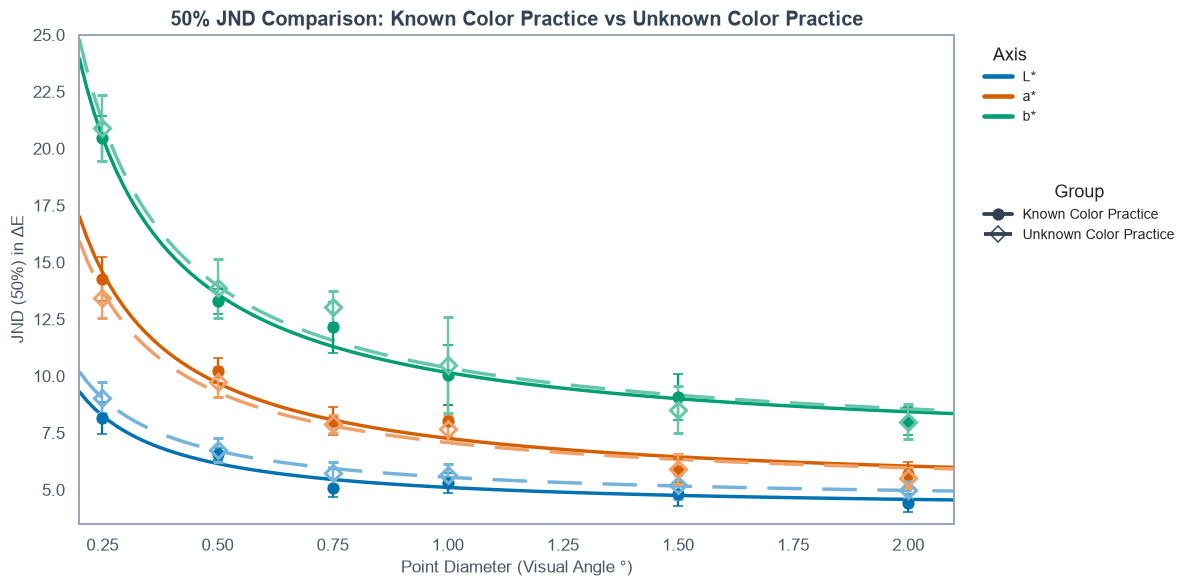

,axis,size_deg,ND50_known,ND50_unknown,difference
0,L,0.25,8.14,9.05,-0.91
1,L,0.50,6.56,6.75,-0.18
2,L,0.75,5.07,5.72,-0.65
3,L,1.00,5.29,5.66,-0.36
4,L,1.50,4.81,5.19,-0.38
5,L,2.00,4.41,4.99,-0.58
6,a,0.25,14.27,13.44,0.83
7,a,0.50,10.24,9.74,0.50
8,a,0.75,8.02,7.89,0.14
9,a,1.00,8.03,7.67,0.35


In [12]:
nd_linear_expert = fit_nd_linear_model(regression_expert)
nd_linear_non_expert = fit_nd_linear_model(regression_non_expert)


def plot_jnd_by_practice_website_style(
    reg_primary,
    nd_primary,
    reg_secondary,
    nd_secondary,
    *,
    primary_label="Known Color Practice",
    secondary_label="Unknown Color Practice",
    title=None,
):
    """Mirror of the dashboard's JNDPlotByExpertise D3 figure.

    Color encodes axis (Okabe–Ito). Style encodes group:
    primary = solid + filled circle; secondary = dashed (10 6) + hollow diamond.
    Both series show empirical ND(50%) ± 1 SE.
    """
    all_sizes = sorted(
        set(reg_primary["size_deg"]).union(reg_secondary["size_deg"]).union(SIZES)
    )
    max_size = max(all_sizes)
    s_grid = np.linspace(JND_PLOT_X_MIN, max_size * 1.05, 120)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    y_hi = JND_PLOT_Y_MIN

    for axis in AXES:
        main = AXIS_COLORS[axis]["main"]
        muted = AXIS_COLORS[axis]["muted"]

        for reg_table, nd_linear, color, dashed, marker, fillstyle in [
            (reg_primary, nd_primary, main, False, "o", "full"),
            (reg_secondary, nd_secondary, muted, True, "D", "none"),
        ]:
            lin = nd_linear[nd_linear["axis"] == axis].iloc[0]
            curve = lin["A"] + lin["B"] / s_grid
            ax.plot(
                s_grid,
                curve,
                color=color,
                linewidth=JND_LINE_WIDTH,
                linestyle=(0, JND_DASH) if dashed else "solid",
                solid_capstyle="round",
            )
            y_hi = max(y_hi, float(np.nanmax(curve)))

            sub = reg_table[reg_table["axis"] == axis].sort_values("size_deg")
            ax.errorbar(
                sub["size_deg"],
                sub["ND50"],
                yerr=sub["ND50_se"],
                fmt=marker,
                color=color,
                markersize=7,
                linestyle="none",
                fillstyle=fillstyle,
                markerfacecolor=color if fillstyle == "full" else "none",
                markeredgecolor=color,
                markeredgewidth=2 if fillstyle == "none" else 1,
                capsize=3,
                elinewidth=1.5,
                capthick=1.5,
                zorder=3,
            )
            y_hi = max(y_hi, float((sub["ND50"] + sub["ND50_se"]).max()))

    color_handles = [
        Line2D([0], [0], color=AXIS_COLORS[axis]["main"], linewidth=3, label=AXIS_LABELS[axis])
        for axis in AXES
    ]
    style_handles = [
        Line2D(
            [0], [0], color=CHART_TEXT_FILL, linewidth=2.5,
            marker="o", markersize=7, label=primary_label,
        ),
        Line2D(
            [0], [0], color=CHART_TEXT_FILL, linewidth=2.5,
            linestyle=(0, JND_DASH), marker="D", markersize=7,
            markerfacecolor="none", label=secondary_label,
        ),
    ]

    ax.set_xlim(JND_PLOT_X_MIN, max_size * 1.05)
    ax.set_ylim(JND_PLOT_Y_MIN, max(5.0, np.ceil(y_hi / 5) * 5))
    ax.set_title(
        title or f"50% JND Comparison: {primary_label} vs {secondary_label}",
        fontsize=13,
        fontweight="bold",
        color=CHART_TEXT_FILL,
    )
    ax.set_xlabel("Point Diameter (Visual Angle °)", fontsize=11, color=CHART_MUTED_FILL)
    ax.set_ylabel("JND (50%) in ΔE", fontsize=11, color=CHART_MUTED_FILL)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color(CHART_AXIS_STROKE)
    ax.tick_params(colors=CHART_AXIS_STROKE, labelcolor=CHART_MUTED_FILL)
    legend1 = ax.legend(
        handles=color_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0),
        frameon=False, fontsize=9, title="Axis",
    )
    ax.add_artist(legend1)
    ax.legend(
        handles=style_handles, loc="upper left", bbox_to_anchor=(1.02, 0.72),
        frameon=False, fontsize=9, title="Group",
    )
    fig.tight_layout()
    plt.show()


plot_jnd_by_practice_website_style(
    regression_expert,
    nd_linear_expert,
    regression_non_expert,
    nd_linear_non_expert,
    primary_label="Known Color Practice",
    secondary_label="Unknown Color Practice",
)

side_by_side = regression_expert.merge(
    regression_non_expert, on=["axis", "size_deg"], suffixes=("_known", "_unknown")
)[["axis", "size_deg", "ND50_known", "ND50_unknown"]]
side_by_side["difference"] = side_by_side["ND50_known"] - side_by_side["ND50_unknown"]
side_by_side.round(2)


### 7. Welch's t-test on participant-level accuracy

The paper's headline extension test: a Welch two-sample t-test comparing participant-level accuracy (proportion of correct standard-trial responses) between the two color-practice groups.

In [13]:
acc = participant_accuracy(analysis_trials)
acc_expert = acc[acc["participantId"].isin(expert_ids)]["accuracy"].to_numpy()
acc_non_expert = acc[acc["participantId"].isin(non_expert_ids)]["accuracy"].to_numpy()

welch = welch_t_test(acc_expert, acc_non_expert)

print(f"Known Color Practice:   mean accuracy = {acc_expert.mean():.3f} "
      f"(SD {acc_expert.std(ddof=1):.3f}, n = {len(acc_expert)})")
print(f"Unknown Color Practice: mean accuracy = {acc_non_expert.mean():.3f} "
      f"(SD {acc_non_expert.std(ddof=1):.3f}, n = {len(acc_non_expert)})")
print(f"\nWelch's t-test: t = {welch['t']:.3f}, df = {welch['df']:.1f}, p = {welch['p']:.2f}")
print("No significant difference between the color-practice groups."
      if welch["p"] >= 0.05 else "Significant difference between groups.")

Known Color Practice:   mean accuracy = 0.564 (SD 0.203, n = 93)
Unknown Color Practice: mean accuracy = 0.563 (SD 0.217, n = 51)

Welch's t-test: t = 0.035, df = 97.4, p = 0.97
No significant difference between the color-practice groups.


## Conclusions

**Replication (Part A).** Our results reproduce the principal findings of Szafir (2018): discriminability increases with color difference and mark size; per-condition through-origin fits are strong; and derived 50% JND thresholds closely track the original values (supplemental Table 1), with the largest discrepancies at the smallest mark size and on the L\* axis.

**Extension (Part B).** Splitting participants by self-reported color practice shows no significant difference in color discrimination — neither in participant-level accuracy (Welch's t-test) nor in the per-axis JND curves, and the result is unchanged when restricted to makeup-colored stimuli. This supports the paper's conclusion that design guidance regarding color discrimination generalizes across viewers regardless of their regular color practice.